# Follow-Along Guides: Evaluate Simple Linear Regression

## Introduction

In this guide, you will use simple linear regression to explore the relationship between two continuous variables. To accomplish this, you will perform a complete simple linear regression analysis, which includes creating and fitting a model, checking model assumptions, analyzing model performance, interpreting model coefficients, and communicating results to stakeholders.

For this guide, you are part of an analytics team that provides insights about marketing and sales. You have been assigned to a project that focuses on the use of influencer marketing, and you would like to explore the relationship between marketing promotional budgets and sales. The dataset provided includes information about marketing campaigns across TV, radio, and social media, as well as how much revenue in sales was generated from these campaigns. Based on this information, leaders in your company will make decisions about where to focus future marketing efforts, so it is critical to have a clear understanding of the relationship between the different types of marketing and the revenue they generate.

This guide will develop your knowledge of linear regression and your skills evaluating regression results which will help prepare you for modeling to provide business recommendations in the future.

## Step 1: Imports

### Import packages

Import relevant Python libraries and packages. In this guide, you will need to use `pandas`, `pyplot` from `matplotlib`, and `seaborn`.

In [1]:
# Import pandas, pyplot from matplotlib, and seaborn.

### YOUR CODE HERE ### 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Import the statsmodel module and the ols function

Import the `statsmodels.api` Python module using its common abbreviation, `sm`, along with the `ols()` function from `statsmodels.formula.api`. To complete this, you will need to write the imports as well.

In [2]:
# Import the statsmodel module.

### YOUR CODE HERE ###
# Import the ols function from statsmodels.
import statsmodels.api as sm
from statsmodels.formula.api import ols

### Load the dataset

`Pandas` was used to load the provided dataset `marketing_and_sales_data_evaluate_lr.csv` as `data`, now display the first five rows. This is a fictional dataset that was created for educational purposes. The variables in the dataset have been kept as is to suit the objectives of this guide. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this guide by completing the following instructions.

In [3]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

### YOUR CODE HERE ###
data = pd.read_csv("marketing_and_sales_data_evaluation_lr.csv")

# Display the first five rows.

### YOUR CODE HERE ### 
data.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


## Step 2: Data exploration

### Familiarize yourself with the data's features

Start with an exploratory data analysis to familiarize yourself with the data and prepare it for modeling.

The features in the data are:
* TV promotion budget (in millions of dollars)
* Social media promotion budget (in millions of dollars)
* Radio promotion budget (in millions of dollars)
* Sales (in millions of dollars)

Each row corresponds to an independent marketing promotion where the business invests in `TV`, `Social_Media`, and `Radio` promotions to increase `Sales`.

The business would like to determine which feature most strongly predicts `Sales` so they have a better understanding of what promotions they should invest in in the future. To accomplish this, you'll construct a simple linear regression model that predicts sales using a single independent variable. 

**Question:** What are some reasons for conducting an EDA before constructing a simple linear regression model?

* The primary reason for conducting an EDA before constructing a simple linear regression model is to look at data before making any assumptions. It can help identify any errors (missing, duplicated, mis-coded data), as well as better understand patterns within the data, detect outliers or anomalous events, find interesting relations among the variables.

### Explore the data size

Calculate the number of rows and columns in the data.

In [4]:
# Display the shape of the data as a tuple (rows, columns).

### YOUR CODE HERE ### 
data.shape

(4572, 4)

### Explore the independent variables

There are three continuous independent variables: `TV`, `Radio`, and `Social_Media`. To understand how heavily the business invests in each promotion type, use `describe()` to generate descriptive statistics for these three variables.

In [5]:
# Generate descriptive statistics about TV, Radio, and Social_Media.

### YOUR CODE HERE ###
data[["TV", "Radio", "Social_Media"]].describe()

,TV,Radio,Social_Media
count,4562.000000,4568.000000,4566.000000
mean,54.066857,18.160356,3.323956
std,26.125054,9.676958,2.212670
min,10.000000,0.000684,0.000031
25%,32.000000,10.525957,1.527849
50%,53.000000,17.859513,3.055565
75%,77.000000,25.649730,4.807558
max,100.000000,48.871161,13.981662


### Explore the dependent variable

Before fitting the model, ensure the `Sales` for each promotion (i.e., row) is present. If the `Sales` in a row is missing, that row isn't of much value to the simple linear regression model.

Display the percentage of missing values in the `Sales` column in the DataFrame `data`.

In [6]:
# Calculate the average missing rate in the sales column.

### YOUR CODE HERE ###
missing_sales = data["Sales"].isna().mean()

# Convert the missing_sales from a decimal to a percentage and round to 2 decimal place.

### YOUR CODE HERE ###
missing_sales = round(missing_sales*100, 2)

# Display the results (missing_sales must be converted to a string to be concatenated in the print statement).

### YOUR CODE HERE ###
print(f"Percentage of promotions missing Sales: {str(missing_sales)}%")

Percentage of promotions missing Sales: 0.13%


**Question:** What do you observe about the percentage of missing values in the `Sales` column?

* The preceeding output shows that 0.13% of rows are missing in the `Sales` value.

### Remove the missing data

Remove all rows in the data from which `Sales` is missing.

In [7]:
# Subset the data to include rows where Sales is present.

### YOUR CODE HERE ### 
data = data.dropna(subset = ["Sales"], axis =0)

### Visualize the sales distribution

Create a histogram to visualize the distribution of `Sales`.

Text(0.5, 1.0, 'Distribution of Sales')

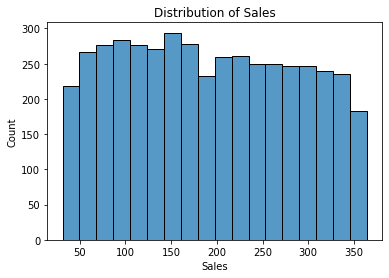

In [8]:
# Create a histogram of the Sales.
fig = sns.histplot(data["Sales"])
fig.set_title("Distribution of Sales")

**Question:** What do you observe about the distribution of `Sales` from the preceding histogram?

* Can be observed that `Sales` are equally distributed between 25 and 350 million

## Step 3: Model building


Create a pairplot to visualize the relationships between pairs of variables in the data. You will use this to visually determine which variable has the strongest linear relationship with `Sales`. This will help you select the X variable for the simple linear regression.

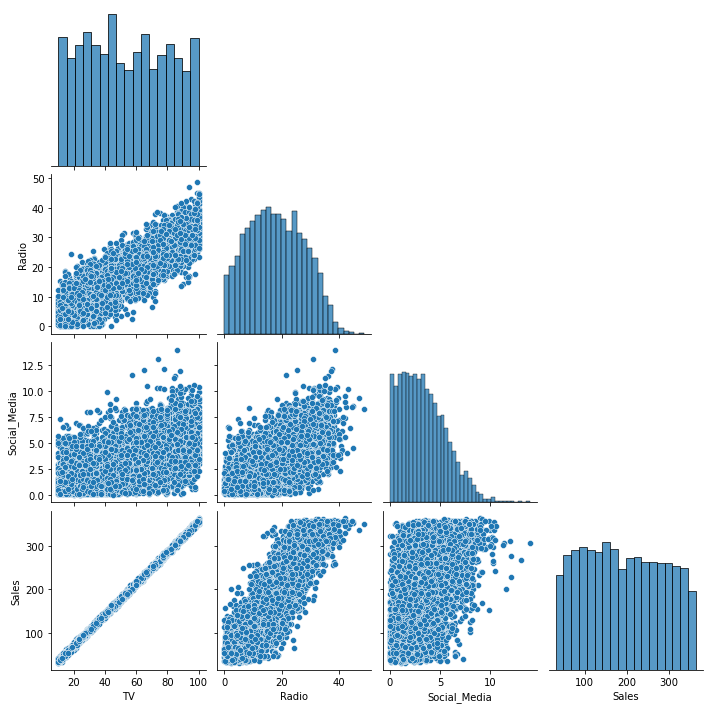

In [9]:
# Create a pairplot of the data.

### YOUR CODE HERE ### 
sns.pairplot(data, corner=True)
plt.show()

**Question:** Which variable did you select for X? Why?

* `TV` clearly has the strongest linear relationship with `Sales`. You could draw a straight line through the scatterplot of `TV` and `Sales` that confidently estimates `Sales` using `TV`. 
`Radio` and `Sales` appears to have a linear relationship, but there is a larger variance than between `TV` and `Sales`.

### Build and fit the model

Replace the comment with the correct code. Use the variable you chose for `X` for building the model.

In [10]:
# Define the OLS formula.
ols_formula = "Sales ~ TV"

# Create an OLS model.
OLS = ols(formula = ols_formula, data=data)

# Fit the model.
model = OLS.fit()
# Save the results summary.
model_results = model.summary()

# Display the model results.
model_results

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.527e+06
Date:                Sat, 22 Mar 2025   Prob (F-statistic):               0.00
Time:                        23:19:14   Log-Likelihood:                -11393.
No. Observations:                4556   AIC:                         2.279e+04
Df Residuals:                    4554   BIC:                         2.280e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1263      0.101     -1.257      0.209      -0.323       0.071
TV             3.5614      0.002   2127.776      0.000       3.558       3.565
==============================================================================
Omnibus:                        0.051   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.975   Jarque-Bera (JB):                0.030
Skew:                           0.001   Prob(JB):                        0.985
Kurtosis:                       3.012   Cond. No.                         138.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Check model assumptions

To justify using simple linear regression, check that the four linear regression assumptions are not violated. These assumptions are:

* Linearity
* Independent Observations
* Normality
* Homoscedasticity

### Model assumption: Linearity

The linearity assumption requires a linear relationship between the independent and dependent variables. Check this assumption by creating a scatterplot comparing the independent variable with the dependent variable. 

Create a scatterplot comparing the X variable you selected with the dependent variable.

Text(0.5, 1.0, 'linear relationship between Sales and tv spend')

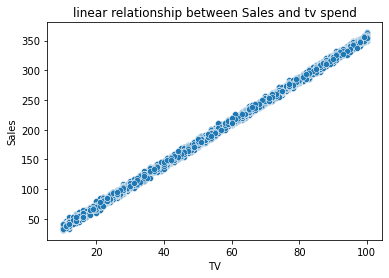

In [11]:
# Create a scatterplot comparing X and Sales (Y).

ax = sns.scatterplot(x=data["TV"], y=data["Sales"])
ax.set_title("linear relationship between Sales and tv spend")

**QUESTION:** Is the linearity assumption met?

* There is a clear linear relationship between `TV` and `Sales`, meeting the linearity assumption.

### Model assumption: Independence

The **independent observation assumption** states that each observation in the dataset is independent. As each marketing promotion (i.e., row) is independent from one another, the independence assumption is not violated.

### Model assumption: Normality

The normality assumption states that the errors are normally distributed.

Create two plots to check this assumption:

* **Plot 1**: Histogram of the residuals
* **Plot 2**: Q-Q plot of the residuals

Text(0.5, 1.0, 'Normal Q-Q plot')

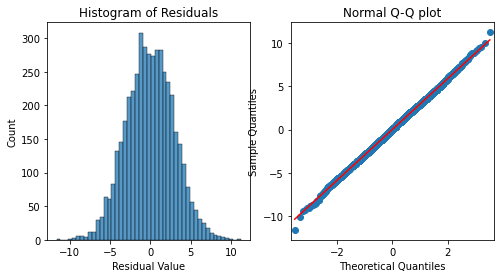

In [12]:
# Calculate the residuals.

### YOUR CODE HERE ### 
residuals = model.resid

# Create a 1x2 plot figures.
fig, axes = plt.subplots(1,2, figsize=(8,4))


# Create a histogram with the residuals. 

### YOUR CODE HERE ### 
sns.histplot(residuals, ax=axes[0])

# Set the x label of the residual plot.
axes[0].set_xlabel("Residual Value")

# Set the title of the residual plot.
axes[0].set_title("Histogram of Residuals")
# Create a Q-Q plot of the residuals.

### YOUR CODE HERE ### 

# Set the title of the Q-Q plot.
sm.qqplot(residuals, line="s", ax=axes[1])
axes[1].set_title("Normal Q-Q plot")

# Use matplotlib's tight_layout() function to add space between plots for a cleaner appearance.

# Show the plot.

**Question:** Is the normality assumption met?

* The histogram of the residuals are approximately normally distributed, which supports that the normality assumption is met for this mode. The residuals in the Q-Q plot form a straight line, further supporting that the normality assumption is met.

### Model assumption: Homoscedasticity

The **homoscedasticity (constant variance) assumption** is that the residuals have a constant variance for all values of `X`.

Check that this assumption is not violated by creating a scatterplot with the fitted values and residuals. Add a line at $y = 0$ to visualize the variance of residuals above and below $y = 0$.

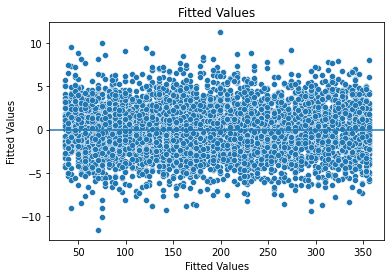

In [13]:
# Create a scatterplot with the fitted values from the model and the residuals.

### YOUR CODE HERE ### 
fig = sns.scatterplot(x=model.fittedvalues, y=model.resid)

# Set the x-axis label.
fig.set_xlabel("Fitted Values")

# Set the y-axis label.
fig.set_ylabel("Fitted Values")
# Set the title.
fig.set_title("Fitted Values")
# Add a line at y = 0 to visualize the variance of residuals above and below 0.

### YOUR CODE HERE ### 
fig.axhline(0)
# Show the plot.
plt.show()

**QUESTION:** Is the homoscedasticity assumption met?

* The variance of the residuals is consistent across all X. Thus, the assumption of homoscedasticity is met

## Step 4: Results and evaluation

### Display the OLS regression results

If the linearity assumptions are met, you can interpret the model results accurately.

Display the OLS regression results from the fitted model object, which includes information about the dataset, model fit, and coefficients.

In [14]:
# Display the model_results defined previously.

### YOUR CODE HERE ###
model_results

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.527e+06
Date:                Sat, 22 Mar 2025   Prob (F-statistic):               0.00
Time:                        23:19:14   Log-Likelihood:                -11393.
No. Observations:                4556   AIC:                         2.279e+04
Df Residuals:                    4554   BIC:                         2.280e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1263      0.101     -1.257      0.209      -0.323       0.071
TV             3.5614      0.002   2127.776      0.000       3.558       3.565
==============================================================================
Omnibus:                        0.051   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.975   Jarque-Bera (JB):                0.030
Skew:                           0.001   Prob(JB):                        0.985
Kurtosis:                       3.012   Cond. No.                         138.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Question:** The R-squared on the preceding output measures the proportion of variation in the dependent variable (Y) explained by the independent variable (X). What is your intepretation of the model's R-squared?


* Using `TV` as X results in a simple linear regression model with R^2 = 0.999. In other words, `TV` explains 99.9% of the variation in `Sales`

* The R^2 value will depend on the variable slected for X.

### Interpret the model results

With the model fit evaluated, assess the coefficient estimates and the uncertainty of these estimates.

**Question:** Based on the preceding model results, what do you observe about the coefficients?

* When `TV` is used as the independent variable X, the coefficient for the `Intercept` is -0.1263 and the coefficient for `TV` is 3.5614.

**Question:** How would you write the relationship between X and `Sales` in the form of a linear equation?

* When `TV` is used as the independent variable X, the linear equation is $$ Y = Intercept + Slope*X $$

$$ Sales(in millions) = Intercept + Slope*TV(in millions) $$
$$ Sales(in millions) = -0.1263 + 3.5614*TV(in millions) $$

**Question:** Why is it important to interpret the beta coefficients?



* Beta coefficients allow you to estimate the magnitude and direction (positive or negative) of the effect of each independent variable on the dependent variable. The coefficient estimates can be converted to explainable insights, such as the connection between an increase in TV promotional budgets and sales mentioned previously.

* According to the model, the `TV` is used as the independent variable X, an increases of one million dollars for the TV promotion budget results in an estimated 3.5614 million dollar more sales


### Measure the uncertainty of the coefficient estimates

Model coefficients are estimated. This means there is an amount of uncertainty in the estimate. A p-value and $95\%$ confidence interval are provided with each coefficient to quantify the uncertainty for that coefficient estimate.

Display the model results again.

In [15]:
# Display the model_results defined previously.

### YOUR CODE HERE ###
model_results

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.527e+06
Date:                Sat, 22 Mar 2025   Prob (F-statistic):               0.00
Time:                        23:19:14   Log-Likelihood:                -11393.
No. Observations:                4556   AIC:                         2.279e+04
Df Residuals:                    4554   BIC:                         2.280e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1263      0.101     -1.257      0.209      -0.323       0.071
TV             3.5614      0.002   2127.776      0.000       3.558       3.565
==============================================================================
Omnibus:                        0.051   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.975   Jarque-Bera (JB):                0.030
Skew:                           0.001   Prob(JB):                        0.985
Kurtosis:                       3.012   Cond. No.                         138.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Question:** Based on this model, what is your interpretation of the p-value and confidence interval for the coefficient estimate of X?

* When `TV` is used as the independent variable, it has a p-value of $0.000$ and a $95\%$ confidence interval of $[3.558,3.565]$. This means there is a $95\%$ chance the interval $[3.558,3.565]$ contains the true parameter value of the slope. These results indicate little uncertainty in the estimation of the slope of X. Therefore, the business can be confident in the impact `TV` has on `Sales`.

**Question:** Based on this model, what are you interested in exploring?

Potential areas to explore include:

* Providing the business with the estimated sales given different TV promotional budgets
* Use `TV` and `Radio` as independent variables.
* Adding plots to help convey the results, such as using `seaborn regplot` to plot the data with the best fit regression line.

**Question:** What recommendations would you make to the leadership at your organization?

* Of the three available promotion types (TV, radio, and social media), TV has the strongest positive linear relationship with sales. According to the model, an increase of one million dollars for the TV promotional budget will result in an estimated 3.5614 million dollars more in sales. This is a very confident estimate, as the p-value for this coefficient estimate is small. Thus, the business should prioritize increasing the TV promotional budget over the radio and social media promotional budgets to increase sales. 


## Considerations

**What are some key takeaways that you learned from this guide?**


* Exploratory data analysis can be used to find a suitable X variable for a simple linear regression model.
* It's important to check that simple linear regression assumptions are met before interpreting model results.
* R-squared is a useful measure of prediction error.
* It's important to provide measures of uncertainty (e.g., p-values, confidence intervals) with any coefficient estimates. 

**What findings would you share with others?**

* Sales is relatively equally distributed between \\$25 and \\$350 million across all promotions. 
* In the data visualization, TV has the strongest linear relationship with sales. Radio and sales appear to have a moderate linear relationship, but there is larger variance than between TV and sales. Social media and sales appear to have a weak linear relationship.
* When TV is used as the independent variable, the R-squared for the simple linear regression model estimating sales is 0.999.
* When TV is used as the independent variable, the coefficient for the intercept is -0.1263 and the coefficient for TV is 3.5614.
* When TV is used as the independent variable, the slope of the coefficient for TV has a p-value of 0.000 and a 95% confidence interval of [3.558, 3.565].


**How would you frame your findings to stakeholders?**

* Among TV, social media, and radio, TV had the strongest positive linear relationship with sales. 
* The linear regression model estimates that 99.9% of the variation in sales is explained by the TV promotional budget. In other words, nearly all of the variation in sales can be explained by the TV promotional budget alone, making TV an excellent predictor of sales.
* According to the model, when TV is used as the independent variable X, an increase of one million dollars for the TV promotional budget would result in an estimated 3.5614 million more dollars in sales. 
* The interval (3.558 million, 3.565 million) has a 95% probability of containing the true estimate of the increase in sales for a one million dollar increase in the TV promotional budget. Therefore, the estimate provided in the previous bullet is very confident.

#### **References**

Saragih, H.S. (2020). [*Dummy Marketing and Sales Data*](https://www.kaggle.com/datasets/harrimansaragih/dummy-advertising-and-sales-data).

Dale, D.,Droettboom, M., Firing, E., Hunter, J. (n.d.). [*Matplotlib.Pyplot.Axline — Matplotlib 3.5.0 Documentation*](https://matplotlib.org/3.5.0/api/_as_gen/matplotlib.pyplot.axline.html). 